In [1]:
!pip install pandas numpy scikit-learn nltk textblob

In [5]:
!pip install datasets

In [9]:
import os

os.environ["KAGGLE_USERNAME"] = "mahak9882"
os.environ["KAGGLE_API_TOKEN"] = "KGAT_b5d8bcbdbc819fdcc999a24a9b85c7068"

In [10]:
!pip install kaggle

In [16]:
!pip install kagglehub

In [17]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("thearijitdas/fake-reviews-dataset")

print("Path to dataset files:", path)

100%|██████████| 4.77M/4.77M [00:01<00:00, 3.14MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/thearijitdas/fake-reviews-dataset/versions/4


In [18]:
import os

os.listdir(path)

['fake_reviews_dataset.csv']

In [19]:
import pandas as pd

file_path = path + "/fake_reviews_dataset.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(40526, 4)


,category,rating,text,label
0,Home_and_Kitchen,5.0,"Love this! Well made, sturdy, and very comfor...",1
1,Home_and_Kitchen,5.0,"love it, a great upgrade from the original. I...",1
2,Home_and_Kitchen,5.0,This pillow saved my back. I love the look and...,1
3,Home_and_Kitchen,1.0,"Missing information on how to use it, but it i...",1
4,Home_and_Kitchen,5.0,Very nice set. Good quality. We have had the s...,1


In [20]:
df = df.rename(columns={"text": "review_text"})

In [21]:
df = df[["review_text","rating","label"]]

In [22]:
df["label"].value_counts()

,count
label,
1,20294
0,20232


In [23]:
print(df.columns)
print(df.shape)

Index(['review_text', 'rating', 'label'], dtype='object')
(40526, 3)


In [24]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z ]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_review"] = df["review_text"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000
max_len = 300

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(df["clean_review"])

X = tokenizer.texts_to_sequences(df["clean_review"])

X = pad_sequences(X, maxlen=max_len)

y = df["label"]

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(32420, 300)
(8106, 300)


In [27]:
from textblob import TextBlob
import numpy as np

df["sentiment"] = df["clean_review"].apply(lambda x: TextBlob(x).sentiment.polarity)

sentiment_feature = np.array(df["sentiment"]).reshape(-1,1)

In [28]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout, Input, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
import tensorflow.keras.backend as K

In [ ]:
# Baseline Model — BiLSTM

In [29]:
bilstm_model = Sequential()

bilstm_model.add(Embedding(20000,128,input_length=300))

bilstm_model.add(Bidirectional(LSTM(64)))

bilstm_model.add(Dense(32,activation="relu"))

bilstm_model.add(Dense(1,activation="sigmoid"))

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history1 = bilstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

loss1, acc1 = bilstm_model.evaluate(X_test,y_test)

print("BiLSTM Accuracy:",acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7816 - loss: 0.4318 - val_accuracy: 0.9025 - val_loss: 0.2319
Epoch 2/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9354 - loss: 0.1627 - val_accuracy: 0.9007 - val_loss: 0.2319
Epoch 3/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9582 - loss: 0.1102 - val_accuracy: 0.9099 - val_loss: 0.2481
Epoch 4/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.9749 - loss: 0.0703 - val_accuracy: 0.9050 - val_loss: 0.2968
Epoch 5/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9841 - loss: 0.0450 - val_accuracy: 0.9035 - val_loss: 0.3264
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9051 - loss: 0.3182
BiLSTM Accuracy: 0.9100666046142578


In [ ]:
# BiLSTM + Attention Layer

In [30]:
class Attention(Layer):

    def build(self,input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer="normal"
        )

        self.b = self.add_weight(
            shape=(input_shape[1],1),
            initializer="zeros"
        )

    def call(self,x):

        e = K.tanh(K.dot(x,self.W)+self.b)

        a = K.softmax(e,axis=1)

        output = x*a

        return K.sum(output,axis=1)

In [31]:
input_layer = Input(shape=(300,))

embedding = Embedding(20000,128)(input_layer)

bilstm = Bidirectional(
    LSTM(64,return_sequences=True)
)(embedding)

attention = Attention()(bilstm)

dense = Dense(32,activation="relu")(attention)

output = Dense(1,activation="sigmoid")(dense)

attention_model = Model(inputs=input_layer,outputs=output)

attention_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = attention_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

loss2, acc2 = attention_model.evaluate(X_test,y_test)

print("Attention Model Accuracy:",acc2)

Epoch 1/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.6121 - loss: 0.6171 - val_accuracy: 0.8742 - val_loss: 0.2864
Epoch 2/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9031 - loss: 0.2219 - val_accuracy: 0.9013 - val_loss: 0.2401
Epoch 3/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9411 - loss: 0.1442 - val_accuracy: 0.8985 - val_loss: 0.2494
Epoch 4/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9565 - loss: 0.1123 - val_accuracy: 0.9059 - val_loss: 0.2720
Epoch 5/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9694 - loss: 0.0802 - val_accuracy: 0.9093 - val_loss: 0.2844
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9091 - loss: 0.2810
Attention Model Accuracy: 0.9094498157501221


In [32]:
# Hybrid Model (Text + Sentiment)

In [33]:
X_train_text, X_test_text, X_train_sent, X_test_sent, y_train2, y_test2 = train_test_split(
    X,
    sentiment_feature,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
text_input = Input(shape=(300,))

embedding = Embedding(20000,128)(text_input)

bilstm = Bidirectional(
    LSTM(64,return_sequences=True)
)(embedding)

attention = Attention()(bilstm)

sentiment_input = Input(shape=(1,))

merged = tf.keras.layers.Concatenate()(
    [attention,sentiment_input]
)

dense = Dense(32,activation="relu")(merged)

output = Dense(1,activation="sigmoid")(dense)

hybrid_model = Model(
    inputs=[text_input,sentiment_input],
    outputs=output
)

hybrid_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

hybrid_model.fit(
    [X_train_text,X_train_sent],
    y_train2,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

loss3, acc3 = hybrid_model.evaluate(
    [X_test_text,X_test_sent],
    y_test2
)

print("Hybrid Model Accuracy:",acc3)

Epoch 1/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.6490 - loss: 0.5635 - val_accuracy: 0.8985 - val_loss: 0.2454
Epoch 2/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9267 - loss: 0.1783 - val_accuracy: 0.9136 - val_loss: 0.2143
Epoch 3/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9549 - loss: 0.1119 - val_accuracy: 0.9164 - val_loss: 0.2233
Epoch 4/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9723 - loss: 0.0709 - val_accuracy: 0.9167 - val_loss: 0.2530
Epoch 5/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9844 - loss: 0.0429 - val_accuracy: 0.9084 - val_loss: 0.3404
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9096 - loss: 0.3481
Hybrid Model Accuracy: 0.9120404720306396


In [35]:
# Model Comparison Table

In [36]:
import pandas as pd

results = {
    "Model":[
        "BiLSTM",
        "BiLSTM + Attention",
        "Hybrid Model"
    ],
    "Accuracy":[
        acc1,
        acc2,
        acc3
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                Model  Accuracy
0              BiLSTM  0.910067
1  BiLSTM + Attention  0.909450
2        Hybrid Model  0.912040


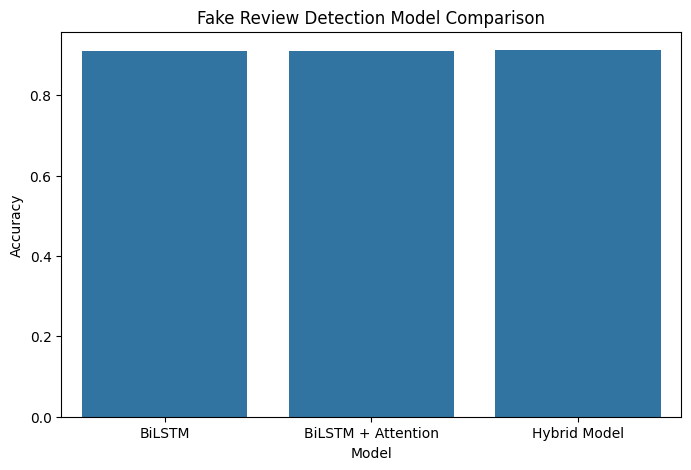

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Fake Review Detection Model Comparison")

plt.show()

In [ ]:
# BERT Model

In [38]:
!pip install transformers torch

In [39]:
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [40]:
texts = df["clean_review"].tolist()
labels = df["label"].tolist()

In [51]:
df = df.sample(n=20000, random_state=42)
df = df.reset_index(drop=True)

In [52]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [53]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = 128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length = 128
)

In [54]:
class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):

        return len(self.labels)

In [55]:
train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

In [56]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [57]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
)

In [58]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions)
    }

In [59]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss
500,0.438726
1000,0.295656
1500,0.256135
2000,0.262123
2500,0.184157
3000,0.158532
3500,0.162706
4000,0.141511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4054, training_loss=0.2360299113470754, metrics={'train_runtime': 1993.788, 'train_samples_per_second': 32.521, 'train_steps_per_second': 2.033, 'total_flos': 4265030207385600.0, 'train_loss': 0.2360299113470754, 'epoch': 2.0})

In [60]:
results = trainer.evaluate()

print(results)

{'eval_loss': 0.21449992060661316, 'eval_accuracy': 0.9353565260301011, 'eval_runtime': 68.4164, 'eval_samples_per_second': 118.48, 'eval_steps_per_second': 7.411, 'epoch': 2.0}
